In [7]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("amazon.csv")

# Check missing values
print("Missing values:\n", df.isnull().sum())

# -------------------------
# STEP 1: Use correct target
# -------------------------

# Convert rating to numeric (in case it's string)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Drop rows where rating is NaN
df = df.dropna(subset=['rating'])

# Convert rating to binary (for classification)
df['rating'] = df['rating'].apply(lambda x: 1 if x >= 4 else 0)

# -------------------------
# STEP 2: Select useful features
# -------------------------

df_model = df[['discounted_price', 'actual_price',
               'discount_percentage', 'rating_count',
               'category', 'rating']]

# Fill missing numeric values with median
for col in ['discounted_price', 'actual_price',
            'discount_percentage', 'rating_count']:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')
    df_model[col].fillna(df_model[col].median(), inplace=True)

# Fill missing category
df_model['category'].fillna("Unknown", inplace=True)

# Encode categorical
df_model = pd.get_dummies(df_model, drop_first=True)

# -------------------------
# STEP 3: Split
# -------------------------

from sklearn.model_selection import train_test_split

X = df_model.drop('rating', axis=1)
y = df_model['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ No error now. Data is clean and ready.")

Missing values:
 product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64
✅ No error now. Data is clean and ready.


C:\Users\Raqib\AppData\Local\Temp\ipykernel_10916\1709751685.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col] = pd.to_numeric(df_model[col], errors='coerce')
C:\Users\Raqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\Raqib\AppData\Local\Temp\ipykernel_10916\1709751685.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on w

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV

pipe_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # <-- Fix here
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

param_lr = {
    'model__C': [0.01, 0.1, 1, 10]
}

grid_lr = GridSearchCV(pipe_lr, param_lr, cv=5, scoring='roc_auc')
grid_lr.fit(X_train, y_train)

print("Best LR Params:", grid_lr.best_params_)

C:\Users\Raqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['discounted_price' 'actual_price' 'discount_percentage']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Raqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['discounted_price' 'actual_price' 'discount_percentage']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Raqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['di

Best LR Params: {'model__C': 0.01}


C:\Users\Raqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['discounted_price' 'actual_price' 'discount_percentage']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Raqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['discounted_price' 'actual_price' 'discount_percentage']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Raqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['di

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, param_rf, cv=5, scoring='roc_auc')
grid_rf.fit(X_train, y_train)

print("Best RF Params:", grid_rf.best_params_)

Best RF Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [15]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

param_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(xgb, param_xgb, cv=5, scoring='roc_auc')
grid_xgb.fit(X_train, y_train)

print("Best XGB Params:", grid_xgb.best_params_)

C:\Users\Raqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [11:53:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Raqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [11:53:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Raqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [11:53:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } 

Best XGB Params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

results = {}

results["Logistic Regression"] = evaluate(grid_lr.best_estimator_)
results["Random Forest"] = evaluate(grid_rf.best_estimator_)
results["XGBoost"] = evaluate(grid_xgb.best_estimator_)

import pandas as pd
results_df = pd.DataFrame(results).T

print(results_df)

                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Logistic Regression  0.767918   0.781022  0.963964  0.862903  0.711807
Random Forest        0.764505   0.768421  0.986486  0.863905  0.725035
XGBoost              0.767918   0.773050  0.981982  0.865079  0.705811


C:\Users\Raqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['discounted_price' 'actual_price' 'discount_percentage']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Raqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['discounted_price' 'actual_price' 'discount_percentage']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


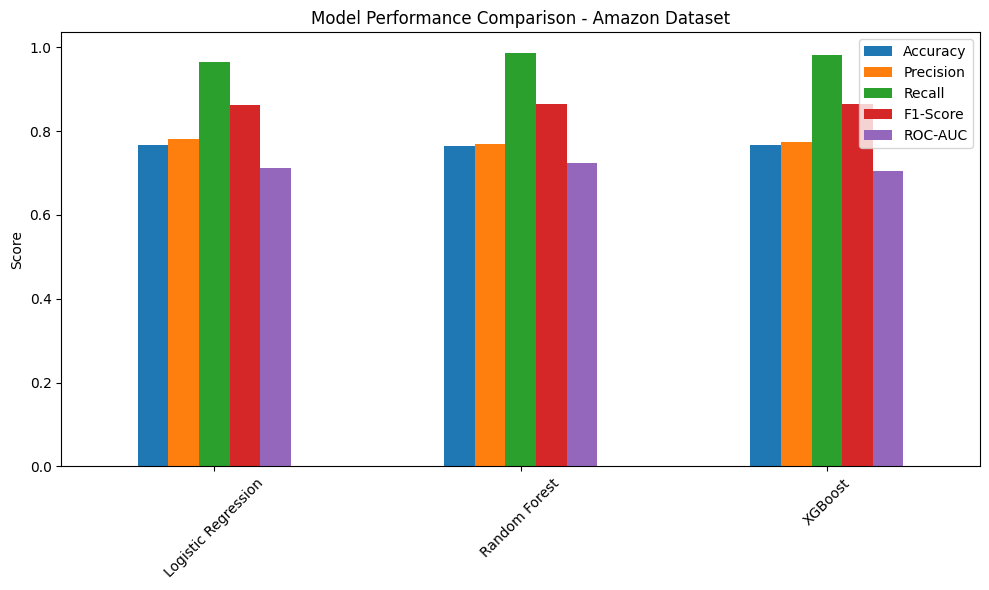

In [17]:
import matplotlib.pyplot as plt

results_df.plot(kind='bar', figsize=(10,6))
plt.title("Model Performance Comparison - Amazon Dataset")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()